In [1]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [2]:
from fastai.vision.all import *
from fastbook import *

In [1081]:
# download MNIST data containing numbers
path = untar_data(URLs.MNIST) # in this case, I get the whole dataset and not just the sample of 3 and 7. 

Path.BASE_PATH = path # setting this to a fastai path object

In [1082]:
path.ls() # to check what is inside. Before, it gave testing. Now it doesnt. Luckily, I have copied it in a validation directory

(#5) [Path('training'),Path('tests'),Path('val_tests'),Path('testing'),Path('validation')]

In [5]:
# let us copy the data from validation into a new testing directory, and other two devoted to tests of validation and testing sets
from distutils.dir_util import copy_tree

# (path/'testing').mkdir(parents = True, exist_ok = True) # creates testing
# copy_tree(path/"validation", path/"testing") # copies the data

# (path/'tests').mkdir(parents = True, exist_ok = True) # creates testing
# copy_tree(path/"validation", path/"tests") # copies the data

# (path/'val_tests').mkdir(parents = True, exist_ok = True) # creates testing
# copy_tree(path/"validation", path/"val_tests") # copies the data


In [1083]:
path.ls() # five folder should appear

(#5) [Path('training'),Path('tests'),Path('val_tests'),Path('testing'),Path('validation')]

In [7]:
# let us check the training folder
(path/'training').ls() # it contains numbers from 0 to 9, meaning that I could use this to train the number classifier

(#10) [Path('training/9'),Path('training/0'),Path('training/7'),Path('training/6'),Path('training/1'),Path('training/8'),Path('training/4'),Path('training/3'),Path('training/2'),Path('training/5')]

# 1) Setting the datasets

## a) training set

In [8]:
# I need to store the images of each number, so I will create two lists (one with names and the other with the images) and join them in a dictionary. 
numbers = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
images_training = [] 
for number in range(10):
    images_training.append((path/'training'/str(number)).ls().sorted())
    print(str(number) + ": " + str(len(images_training[number]))) # this shows how many images there are for each number. ~6000 

0: 5923
1: 6742
2: 5958
3: 6131
4: 5842
5: 5421
6: 5918
7: 6265
8: 5851
9: 5948


In [9]:
# once the images are stores, I can assign them to each variable by joinin them in a dictionary
training_set = {
                number:image for (number,image) in zip(numbers, images_training)
                }

In [10]:
# let us check if the images correspond to the names for some numbers: zero, five, and nine
im0_path = training_set['zero'][95] 
im0 = Image.open(im0_path)

im5_path = training_set['five'][2380] 
im5 = Image.open(im5_path)
im5

im9_path = training_set['nine'][1982] 
im9 = Image.open(im9_path)
im9

# I tried different indexes for the three numbers and in all cases the returned images corresponds with the number. 
# So the training set is ready

## b) validation and testing set

These sets are not splitted within the directories so we need to do a "manual" splitting to put some images in a validation directory and the rest in a testing directory. I am going to use both eventually: validation to see the performance with a given set of hyperparameters and testing to assess model's final performance.

One should be catious when performing the aforementioned splitting. To do it randomly is an option, although in some cases it may give poor results (see section "Validation Sets and Test Sets" in chapter 1 of fastai book). In this case, the splitting will be random. This dataset was balanced by NIST to avoid biases towards numbers drawn by experts (i.e., well-defined numbers). It is well mixed so random splitting does not favor any specific features in the validation/testing sets. 

In [11]:
# first, I want to see how many TOTAL images we have for each number, also counting the training images
numbers = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
images_training = [] 
images_val_test = []
total_images = []
for number in range(10):
    images_training.append((path/'training'/str(number)).ls().sorted())
    images_val_test.append((path/'testing'/str(number)).ls().sorted())
    total_images.append(len(images_training[number]) + len(images_val_test[number])) 

In [12]:
len(images_val_test[0]), len(images_training[0])

(980, 5923)

In [13]:
# now let's calculate the proportions of the images in each dataset
training_proportion = [len(images_training[number])/total_images[number] for number in range(10)]
val_test_proportion = [len(images_val_test[number])/total_images[number] for number in range(10)] 

print("proportion of images in training set for each number: " + str([round(i, 2) for i in training_proportion]))
print("proportion of images in validation/test set for each number: " + str([round(i, 2) for i in val_test_proportion]))

proportion of images in training set for each number: [0.86, 0.86, 0.85, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86]
proportion of images in validation/test set for each number: [0.14, 0.14, 0.15, 0.14, 0.14, 0.14, 0.14, 0.14, 0.14, 0.14]


With this in mind, I choose this splitting: ~10% of total images is for validation and the remaining ~4% is for testing.

### b.1) how I could split the testing-validation set (MNIST gives the whole thing together) into validation and testing individual sets?

In [14]:
# test to see how I can do the splitting
testing_dir = np.array((path/'testing'/'9').ls()) # first, I create a copy of one of the numbers. 9 in this case

# construct a new Generator with the default BitGenerator (PCG64) so I can access the distributions and create lists containing random indexes
rng = np.random.default_rng() 
# this produces an array of random indexes of size matching ~4% of the total pictures (testing set)
# replace = False is to *not* produce duplicated indexes
testing_index = rng.choice([i for i in range(len(testing_dir))], 
                           size = round(len(testing_dir)*(0.04/(0.04+0.10))), 
                           replace = False) 

# creates a mask of True for all indexes that are in testing_index so the new array contains only indexes in testing_index
mask = np.zeros(len(testing_dir), dtype=bool)
mask[testing_index] = True
testing_files = testing_dir[mask]
print("is the size of the test dataset correct?")
print(len(testing_files)==len(testing_index)) # this should contain the same number of elements as the testing_index

# similarly, the training set should contain all those elements the indexes of which ARE NOT present in testing_index
mask = np.ones(len(testing_dir), dtype=bool)
mask[testing_index] = False 
validation_files = testing_dir[mask]
print("is the size of the validation dataset correct?")
print(len(validation_files)==(len(testing_dir) - len(testing_index))) # validation set should contain the total number of pics minus the test set pics

# and let us check the proportions with respect to the TOTAL amount of pictures in the dataset and see if it matches the proposed 0.1 and 0.04 split
validation_proportion = len(validation_files)/total_images[9]
testing_proportion = len(testing_files)/total_images[9]
print("validation and test sets proportion with respect to the total number of images")
print(round(validation_proportion, 2), round(testing_proportion, 2))


is the size of the test dataset correct?
True
is the size of the validation dataset correct?
True
validation and test sets proportion with respect to the total number of images
0.1 0.04


In [15]:
# and we can check that indeed these arrays contain pictures
Image.open(validation_files[81]) 

In [16]:
# and we can check that indeed these arrays contain pictures
Image.open(testing_files[97]) 

*IMPORTANT*: the block below should not be executed more than once, as each execution deletes a percentage of images in both the validation and testing sets. Thus, several executions lead to a complete deletion of the datasets. 

Once the block is executed, the sizes of each dataset are printed and so their respective proportions with respect to the complete datase (in percentages). As discussed above, such splitting is: ~10% of data goes to validation and ~4% is for testing. Check that those are the figures in the printed messages!

## b.2) original testing dataset splitting into testing and validation datasets using the logic explained above

In [17]:
rng = np.random.default_rng() 

for number in range(0, 10):
    reference_dir = (path/'testing'/str(number)).ls() # this is the original testing set downloaded from MNIST. It remains unchanged
    test_dir = np.array((path/'tests'/str(number)).ls()) # this is the testing directory
    val_dir = np.array((path/'val_tests'/str(number)).ls()) # this is the validation directory
    
    # build testing set: random splitting
    testing_index = rng.choice([i for i in range(len(reference_dir))], 
                               size = round(len(reference_dir)*(0.04/(0.04+0.10))), 
                               replace = False)
    
    mask = np.ones(len(reference_dir), dtype=bool)
    mask[testing_index] = False # all values in testing indexes are False so I do not remove them (to have the testing set)
    
    # removes images not contained in testing_index: creates the testing set
    # for image in test_dir[mask]:
    #     (image).unlink()

    print(f"for number {number}, testing set size is: {len((path/'tests'/str(number)).ls())}")
    print(f"for number {number}, test size proportion is: {len((path/'tests'/str(number)).ls())/total_images[number]}")
    
    mask_validation = np.zeros(len(reference_dir), dtype=bool)
    mask_validation[testing_index] = True # all values in testing indexes are True so I remove them (to obtain the validation set)

    # removes images in testing_index: creates the validation set
    # for image in val_dir[mask_validation]:
    #     (image).unlink()

    print(f"for number {number}, validation set size is: {len((path/'val_tests'/str(number)).ls())}")
    print(f"for number {number}, validation size proportion is: {len((path/'val_tests'/str(number)).ls())/total_images[number]}\n")


for number 0, testing set size is: 280
for number 0, test size proportion is: 0.040562074460379544
for number 0, validation set size is: 700
for number 0, validation size proportion is: 0.10140518615094886

for number 1, testing set size is: 324
for number 1, test size proportion is: 0.041132410816300626
for number 1, validation set size is: 811
for number 1, validation size proportion is: 0.10295797892598706

for number 2, testing set size is: 295
for number 2, test size proportion is: 0.04220314735336195
for number 2, validation set size is: 737
for number 2, validation size proportion is: 0.10543633762517883

for number 3, testing set size is: 289
for number 3, test size proportion is: 0.04047052233580731
for number 3, validation set size is: 721
for number 3, validation size proportion is: 0.10096625122531858

for number 4, testing set size is: 281
for number 4, test size proportion is: 0.041178194607268466
for number 4, validation set size is: 701
for number 4, validation size pro

In [18]:
# a manual check to one of the previous results: could be for any number between 0 and 9 and should match the output above
number_check = 7

size_validation = len((path/f'val_tests/{number_check}').ls())
size_test = len((path/f'tests/{number_check}').ls())

print(f"test set size of number {number_check}: {size_test}\nvalidation set size of number {number_check}: {size_validation}\n")

test set size of number 7: 294
validation set size of number 7: 734



Note that the directories to be used are: 

- training: "training"
- validation: "val_tests"
- testing: "tests"

"testing" and "validation" directories remain untouched as they contain the original data so are useful as backups in case I do something wrong.

## c) converting images to tensors and storing them 

<Axes: >

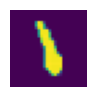

In [19]:
# to deal with an image as a tensor or an array it is first needed to open it using Image from PIL library
# let us create these structures for the training, validation, and testing sets
training_data = {}
validation_data = {}
testing_data = {}
for number in range(10):
    o_train = (path/f'training/{number}').ls()
    o_validation = (path/f'val_tests/{number}').ls()
    o_testing = (path/f'tests/{number}').ls()
    
    # we need to create a tensor containing each image as a tensor 
    # the dimension of this image-containing tensor is => (# of images, image_pixels_x, image_pixel_y) 
    # we divide by 255 to normalize each pixel value (the maximum is 255 in this case)
    # and we do this for all datasets
    training_data[str(number)] = torch.stack([tensor(Image.open(image)) for image in o_train]).float()/255 
    validation_data[str(number)] = torch.stack([tensor(Image.open(image)) for image in o_validation]).float()/255 
    testing_data[str(number)] = torch.stack([tensor(Image.open(image)) for image in o_testing]).float()/255

# is it possible to still open the images? 
show_image(validation_data['1'][294])

## d) flattening the datasets and use them to build the labels

In [1031]:
# this structure is needed to build the Dataset as defined in Pytorch. This will be used later but I will build them now
x_training = []
y_training = []

for number in range(10):
    x_training += training_data[str(number)] # list containing all images as pixels, i.e., each represented as [28, 28] tensors
    y_training += [number]*len(training_data[str(number)]) # creates the labels. The label is the number itself
    
x_training = torch.cat(x_training).view(-1, 28*28) # concatenates all images and decompress them as tensors of length 28*28
x_training.shape # number of images, 784 (784 are the number of pixels in an image: 28*28)

y_training = tensor(y_training).unsqueeze(1) # this is to make it a matriz nx1, n being the number of training images: 59999
y_training.shape # number of images, 1 

print(x_training.shape, y_training.shape) # both arrangements should have same number of rows -> number of trainig images

dset_training = list(zip(x_training,y_training)) # form needed for pytorch: list of tuples (image in pixels, label)
print(dset_training[0][0].shape, dset_training[0][1]) # size of the first image (in pixels: 28*28), its corresponding label

torch.Size([59999, 784]) torch.Size([59999, 1])
torch.Size([784]) tensor([0])


the above should be done for all datasets so I will do this through a function

In [1032]:
def flat_and_label(data):
    values = []
    labels = []
    for number in range(10):
        values += data[str(number)] 
        labels += [number]*len(data[str(number)])
    
    values = torch.cat(values).view(-1, 28*28)
    labels = tensor(labels).unsqueeze(1)

    return (values, labels)        

In [1033]:
x_validation, y_validation = flat_and_label(validation_data)
dset_validation = list(zip(x_validation,y_validation))

x_test, y_test = flat_and_label(testing_data)
dset_testing = list(zip(x_test,y_test))

# 2) Training: linear classifier

## a) initialization of weights (slopes and intercepts)

init_params produces an array of shape (n x m) of random values, where n and m are given by size. n may represent the number of pixels of an image. This is used to define weights (w_i) and intercepts (b_i, also called biases). Each flattened image has a shape = 1 x n (n are the number of pixels in the image), so that when it multiplies a weight matrix of n x 1, it produces a number (size 1 x 1). This number can then add an intercept b_i and produces the prediction.

summary: pixels @ w_i + b_i ---> (1 x n) . (n x 1) + (1 x 1) --> (1 x 1)

In [23]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_() 

In [24]:
weights = init_params((28*28,1))
bias = init_params((1))
print(weights.shape, bias.shape) # note that w_i should be

torch.Size([784, 1]) torch.Size([1])


In [25]:
# this efficiently applies the linear equation to the input data
# note: thanks to broadcasting, the bias can still be defined as a 1 x 1 array and python knows how to handle it
def linear1(xb): return xb@weights + bias

In [26]:
# result for each image upon applying the linear equation using the weights and intercepts
preds = linear1(x_training)
preds.shape 

torch.Size([59999, 1])

I need a proxy of the probability of certain image being a number between 0 and 9. For the binary case, this worked by applying the sigmoid function to the prediction, yielding a value between 0 and 1, which is assumed to be the probability of the image being one of the numbers (P1). The probability of the image being the other number is thus 1 - P1. 

This case is a multiple classification problem so a generalization of the binary approach may be useful. I think this can be done in two ways. In the first one, we treat each number as a binary case: the image is either the specific number or not, with P1 and 1 - P1 probabilities, respectively, calculated from the sigmoid function. Namely, perform the same approach as in the binary case for each number (10 times). In the second one we produce a probability distribution of the image being a number between 0 and 9 using a softmax function. I will try to follow the second. 


In [27]:
# so the first thing is to test if this actually yields what I think
# I need more parameters now. If I am testing numbers between 0 and 9, I will need a 784 x 10 matrix, each column containing the params
# for each number

nums = 10 # numbers between 0 and 9
weights = init_params((28*28,10)) # for each number, pixels of the image (28*28 = 784) combine with weights
bias = init_params((10)) # values to be added to the pixels for each number
print(weights.shape, bias.shape) # note that w_i should be

pred1 = linear1(x_training[0]) # predictions of one image! 
pred1

torch.Size([784, 10]) torch.Size([10])


tensor([  7.4915,   1.0038,   4.9246,  -2.0224, -12.7486,  -0.6027,   4.3514, -11.2741,   0.3180,  24.1057], grad_fn=<AddBackward0>)

what do we do with these predictions? These are crazy numbers... How to get the probability proxy from them? As we are following the second approach, it suffices to use the softmax function that assigns values between 0 and 1 to each prediction constraining their sum to be 1

In [435]:
m = torch.nn.Softmax(dim = 0) # is 0 to express the addition along the row axis?
probs1 = m(pred1)
probs1 # these are the probabilities of ONE image of being a number between 0 and 9

# I think here we should use the scaling...

tensor([6.0889e-08, 9.2679e-11, 4.6747e-09, 4.4949e-12, 9.8717e-17, 1.8590e-11, 2.6354e-09, 4.3127e-16, 4.6679e-11, 1.0000e+00], grad_fn=<SoftmaxBackward0>)

the other approach is using the sigmoid for each number and use that as a probability of being that number

In [29]:
probs2 = torch.sigmoid(pred1)
probs2
# here I have more doubts. What if two numbers have the same probabilty?

tensor([9.9944e-01, 7.3180e-01, 9.9279e-01, 1.1687e-01, 2.9064e-06, 3.5372e-01, 9.8728e-01, 1.2697e-05, 5.7883e-01, 1.0000e+00], grad_fn=<SigmoidBackward0>)

In [575]:
# doing it for all images
pred_all = linear1(x_training) # predictions of training images 
pred_all_scaled = (pred_all - pred_all.mean())/pred_all.std()
m_all = torch.nn.Softmax(dim = 1) # applies softmax to elements of each row, which are the ten predictions (elements) of each image (row)
probs_all = m_all(pred_all_scaled)
probs_all.shape # shape must be N x 10, N is the number of images. I.e., each image has a "probability" of being a number between 0 to 9
probs_all.sum() # as the probabilities of each image should add up to 1, the sum of probabilities must equate the number of images

tensor(59999., grad_fn=<SumBackward0>)

In [578]:
probs_all

tensor([[0.0946, 0.1115, 0.0202,  ..., 0.0116, 0.1925, 0.0203],
        [0.2827, 0.1229, 0.0195,  ..., 0.1971, 0.0368, 0.0227],
        [0.4172, 0.0974, 0.0100,  ..., 0.0051, 0.0701, 0.0052],
        ...,
        [0.0933, 0.0918, 0.1111,  ..., 0.0405, 0.1199, 0.0308],
        [0.0589, 0.1768, 0.2218,  ..., 0.0207, 0.0505, 0.1073],
        [0.2123, 0.3288, 0.1374,  ..., 0.0352, 0.0240, 0.0289]], grad_fn=<SoftmaxBackward0>)

## b) loss function

Now it is necessary to define a loss function to optimize the parameters. An alternative is to use the probability of making accurate predictions, so for each number we may use the corresponding probability obtained from softmax. If done for all numbers, an average accuracy value can be estimated and be used as loss function.

In [700]:
# loss consi|dering the whole training set
rows = torch.arange(probs_all.shape[0]) 
element = y_training.squeeze(1) # flattens y_training to have a tensor of dimension N
loss_probs = 1 - probs_all[rows, element] # for each element in probs_all, subtracts from 1 the corresponding prob. of the number in y_training 
loss_probs.mean() # thus, we want to minimize this value: the closer the prob. is to 1, the better

tensor(0.8988, grad_fn=<MeanBackward0>)

In [701]:
# test to see if matches the value for one image
loss_prob_ = 1 - probs_all[10][y_training.squeeze(1)[10]] # tenth image loss 
loss_prob_ - loss_probs[10] # this should be zero

tensor(0., grad_fn=<SubBackward0>)

In [702]:
def classifier_loss(predictions, labels): # predictions are the output of the linear model. This function transforms those into probabilities
    m_all = torch.nn.Softmax(dim = 1)
    probs_all = m_all(predictions)
    rows = torch.arange(predictions.shape[0])
    targets = labels.squeeze(1)
    return (1 - probs_all[rows, targets]).mean()

In [703]:
classifier_loss(pred_all, y_training)

tensor(0.8907, grad_fn=<MeanBackward0>)

## c) optimization step: changing the parameters

we are going to use minibatches in the optimization. The size of each minibatch is a hyperparameter. 

In [723]:
# this creates minibatches of data in the training set. The size indicates how many training data composes each batch
len(list(DataLoader(x_training, batch_size = 600, shuffle = True)))

100

however, minibatches should also contain the label (or dependent variable) of each training data. We need a tensor containing a tuple pair (independent data, dependent data) to properly build the so-called Dataset. We already have a function to obtain the tuple arrays as we need it! (flat_and_label)

In [724]:
x_training, y_training = flat_and_label(training_data)
data_training = list(zip(x_training,y_training))
print(data_training[1341][0].shape, data_training[1341][1]) # random test on testing data to see if shape and labelling are ok

torch.Size([784]) tensor([0])


In [725]:
training_minibatches = DataLoader(data_training, batch_size = 100, shuffle = True)
#list(training_minibatches)[0] # each minibatch is composed by the image (pixel values) and the corresponding label

putting all together: 
1) initialize weights
2) create minibatches for training, testing, and validation ---> DataLoader(batch_size)
3) get predictions for each minibatch ---> linear1() 
4) calculate loss for each minibatch ---> classifier_loss()
5) calculate gradients of loss with respect to the weights  ---> loss.backward()
6) update parameters using learning rate and calculated gradients: parameter_current -= parameter_prior * learning_rate
7) estimate each batch accuracy (using the validation set)
8) estimate epoch accuracy on validation set (using all batches accuracies)
9) repeat until performance is good enough

In [865]:
# first a test using small datasets
# 1)
weights = init_params((28*28,10)) # for each number, pixels of the image (28*28 = 784) combine with weights
bias = init_params((10)) # values to be added to the pixels for each number
weights.shape, bias.shape

(torch.Size([784, 10]), torch.Size([10]))

In [866]:
# 2) 
image_data_b, label_b = first(training_minibatches)
image_data_b.shape, label_b.shape

(torch.Size([100, 784]), torch.Size([100, 1]))

In [867]:
# 3) this is a test of a small one
training_batch = x_training[:4]
training_batch.shape

torch.Size([4, 784])

In [868]:
# and the predictions of the small batch
training_preds = linear1(training_batch)
training_preds.shape

torch.Size([4, 10])

In [869]:
# 4) this is the calculation of loss for the small minibatch
# maybe scale the predictions? Otherwise, the resultant distribution is biased towards one number only and makes the loss insensible to 
# the parameters
training_preds_scaled = (training_preds - training_preds.mean())/training_preds.min()
m_small = torch.nn.Softmax(dim = 1)
probs_small = m_small(training_preds_scaled)
rows = torch.arange(probs_small.shape[0])
targets = y_training[:4].squeeze(1)

loss = classifier_loss(training_preds_scaled, y_training[:4])
loss.backward()
loss, weights.grad.shape, weights.grad.mean(), bias.grad

(tensor(0.9025, grad_fn=<MeanBackward0>),
 torch.Size([784, 10]),
 tensor(1.0571e-05),
 tensor([ 0.0041, -0.0005, -0.0003, -0.0006, -0.0003, -0.0004, -0.0005, -0.0003, -0.0004, -0.0003]))

In [909]:
# we can unify things in a function to get the loss (4)
def calc_grad(image_data, label, model):
    preds = model(image_data)
    preds_scaled = (preds - preds.mean())/preds.std() # this is the scaling addition to "unflatten" the loss
    loss = classifier_loss(preds_scaled, label)
    loss.backward()
    
calc_grad(training_batch, y_training[:4], linear1) # calculated gradients are added to gradients that were calculated before. Thus, weights.grad.zero_() and bias.grad.zero_() are needed
weights.grad.shape,weights.grad.mean(),bias.grad 

(torch.Size([784, 10]),
 tensor(-1.1662e-06),
 tensor([-0.0098, -0.0039, -0.0008,  0.0028, -0.0001,  0.0015,  0.0029,  0.0033,  0.0030,  0.0012]))

In [910]:
# set gradients to zero so the calculation in a new iteration does not add the ones previously calculated
weights.grad.zero_()
bias.grad.zero_();

In [911]:
# 5) and 6)
def train_epoch(model, lr, params): # now this takes into account ALL the minibatches 
    for image_data, label in training_minibatches:
        calc_grad(image_data, label, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [912]:
# 7) 

# to proceed, first create validation dataset in the proper form. Follow the same procedure carried for the training dataset
x_validation, y_validation = flat_and_label(validation_data)
data_validation = list(zip(x_validation,y_validation))
validation_dataset = DataLoader(data_validation, batch_size = 100, shuffle = True)

# then determine if predictions are adequate. To do so, 
# i) take an image
# ii) estimate probabilities of it being a number between 0 and 9 
# iii) take the highest probability
# iv) Does the index corresponding to the max. probability match the label? If it does, prediction is okay 

# i) example for one validation batch of four elements (similar to the test done for the training set)
validation_batch = x_validation[:4]
validation_preds = linear1(validation_batch)
validation_preds_scaled = (validation_preds - validation_preds.mean())/validation_preds.std()
m = torch.nn.Softmax(dim = 1)
# ii) calculate probability of each image being a number between 0 and 9
validation_probs = m(validation_preds_scaled)
# iii) fetches the maximum probabilities of each image and its index, corresponding to the predicted number
validation_max_probs = validation_probs.max(dim = 1)[0] 
prediction = validation_probs.max(dim = 1)[1] 
# iv) compares the predicted number and the label, and computes the mean value of correct predictions
targets = y_validation[:4].squeeze(1) # label 
correct = (prediction == targets_).float().mean() # comparison
correct

tensor(1.)

In [913]:
prediction

tensor([0, 0, 0, 0])

In [914]:
# 7 as a function
def batch_accuracy(predictions, label):
    preds_scaled = (predictions - predictions.mean())/predictions.std()
    m = torch.nn.Softmax(dim = 1)
    probs = m(preds_scaled)
    max_probs = probs.max(dim = 1)[0]
    pred_num = probs.max(dim = 1)[1]
    targets = label.squeeze(1)
    return (pred_num == targets).float().mean()

In [915]:
batch_accuracy(linear1(validation_batch), y_validation[:4]) # should be the same as the example above

tensor(1.)

In [1041]:
# 8 
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in validation_dataset]
    return round(torch.stack(accs).mean().item(), 4)

## d) putting all in a sequence

In [917]:
weights = init_params((28*28,10)) # for each number, pixels of the image (28*28 = 784) combine with weights
bias = init_params((10)) # values to be added to the pixels for each number
weights.shape, bias.shape

# value using random parameters
print("validation accuracy with random parameters: ", validate_epoch(linear1))

# value with one update of the parameters
lr = 1
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)
print("validation accuracy after one update of parameters using the loss gradient: ", validate_epoch(linear1))

print("validation accuracy for 30 iterations updating the parameters")

for i in range(30):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

validation accuracy with random parameters:  0.1007
validation accuracy after one update of parameters using the loss gradient:  0.3809
validation accuracy for 30 iterations updating the parameters
0.6335 0.713 0.7406 0.7579 0.7714 0.7823 0.7949 0.8007 0.8062 0.8106 0.8118 0.814 0.8172 0.8198 0.8204 0.8237 0.8253 0.8274 0.8283 0.8292 0.8298 0.8316 0.8314 0.8331 0.8348 0.8356 0.8363 0.8348 0.8375 0.8365 

# 3) Create an optimizer for the linear classifier

here is the development of an optimizer, which is exactly what we did before: choose parameters to minimize a loss function.

In [946]:
# Pytorch way to create a linear model (is a method of the nn.Module class)
linear_model = nn.Linear(28*28,10) 

w,b = linear_model.parameters() # retrieves the parameters
w.shape,b.shape
w

Parameter containing:
tensor([[-0.0077, -0.0277,  0.0330,  ..., -0.0253,  0.0290, -0.0228],
        [-0.0213, -0.0182,  0.0199,  ...,  0.0140, -0.0022,  0.0062],
        [ 0.0295,  0.0172, -0.0003,  ...,  0.0074, -0.0320, -0.0077],
        ...,
        [-0.0110,  0.0073,  0.0352,  ...,  0.0333, -0.0138, -0.0345],
        [-0.0282,  0.0249, -0.0217,  ..., -0.0219, -0.0094, -0.0333],
        [ 0.0115,  0.0276, -0.0199,  ..., -0.0005, -0.0190, -0.0257]], requires_grad=True)

In [948]:
class BasicOptim: # this is the basic optimizer
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [949]:
opt = BasicOptim(linear_model.parameters(), lr)

In [950]:
def train_epoch(model):
    for xb,yb in training_minibatches:
        calc_grad(xb, yb, model)
        opt.step() # automatically updates the parameters
        opt.zero_grad() # removes parameters values

In [951]:
# trains the model by going through all minibatches
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [952]:
train_model(linear_model, 30)

0.8508 0.8485 0.8583 0.8509 0.8562 0.846 0.8495 0.8522 0.8587 0.8522 0.853 0.8506 0.849 0.8537 0.8511 0.8494 0.8486 0.8511 0.8506 0.8509 0.8495 0.8453 0.8472 0.8458 0.8502 0.8526 0.8489 0.847 0.851 0.8504 

In [954]:
# SGG is a fastai class that does the same as BasicOptim
linear_model = nn.Linear(28*28,10)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.8539 0.8543 0.8507 0.853 0.8485 0.8541 0.8539 0.8524 0.8422 0.8539 0.8512 0.8559 0.8541 0.8515 0.8487 0.847 0.8478 0.8542 0.8529 0.8499 

In [1073]:
# fastai Learner is a substitute of training_model: we need as input training and validation dataloaders
dls = DataLoaders(training_minibatches, validation_dataset)

# creation of the Lerner
learn = Learner(dls, nn.Linear(28*28,10), opt_func=SGD,
                loss_func=classifier_loss, metrics=batch_accuracy)

# fitting of the learner
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.134255,0.124806,0.902115,00:00
1,0.115389,0.106214,0.913738,00:00
2,0.105801,0.098703,0.918779,00:00
3,0.099006,0.094650,0.920039,00:00
4,0.092750,0.091762,0.923260,00:00
5,0.092739,0.089467,0.923400,00:00
6,0.093973,0.088411,0.923680,00:00
7,0.090974,0.087119,0.925501,00:00
8,0.089121,0.085283,0.926341,00:00
9,0.088519,0.084629,0.928021,00:00


Test to see if I can predict a number from the testing dataset

In [1074]:
# these are the optimized parameters from the Learner
optimized_weights = [*learn.parameters()][0]
optimized_bias = [*learn.parameters()][1]

# I choose an unseen image of a number, from the testing dataset
def number_classifier(N):
    pred = dset_testing[N][0]@optimized_weights.T+b
    pred_scaled = (pred - pred.mean())/pred.std()
    pred_scaled
    m_all = torch.nn.Softmax()
    probs_all = m_all(pred_scaled)

    pred_number = probs_all.max(dim = 0)[1]

    print(f"the predicted number is {pred_number}")

    if pred_number == dset_testing[N][1]:
        print("you made a good prediction!")
    else:
        print(f"you are wrong. The number is {dset_testing[N][1]}")

number_classifier(91)

the predicted number is 0
you made a good prediction!


In [1042]:
# PENDING: Calculate the accuracy on the test set

# 4) Now let us do it with a neural network

In [1075]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30), # this is the first linear operation
    nn.ReLU(), # the output of such operation is then non-linearized using a ReLU
    nn.Linear(30,10) # finally, the output is then operated in a linear equation
)

In [1076]:
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=classifier_loss, metrics=batch_accuracy)

In [1077]:
#hide_output. First are the epochs and then the learning rate. These are hyperparameters that can be optimized too...
learn.fit(100, 0.1) # as the model is more complex, I put more epochs and a lower learing rate

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.279965,0.248468,0.817252,00:00
1,0.199226,0.188239,0.838258,00:00
2,0.181142,0.174409,0.843159,00:00
3,0.177774,0.166749,0.848060,00:00
4,0.171805,0.163248,0.849181,00:00
5,0.166757,0.159458,0.851281,00:00
6,0.134865,0.126839,0.894693,00:00
7,0.106398,0.102725,0.913317,00:00
8,0.099721,0.093323,0.921720,00:00
9,0.092701,0.088902,0.923960,00:00


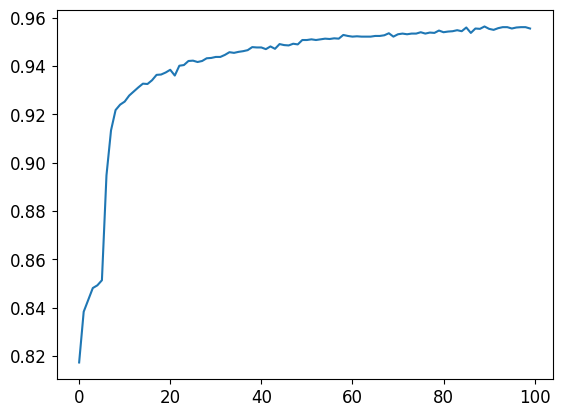

In [1078]:
plt.plot(L(learn.recorder.values).itemgot(2))